# Ablation & Learning Curve Visualization

This notebook visualises the ablation experiments and learning curves
for the logistics delay prediction model (CatBoost, temporal CV).

**Contents:**

1. **Feature ablation bar** — leave-one-out AUC change when each feature is removed.
2. **Cumulative learning curves** — sequential feature addition with a detailed index table.
3. **Geographic ablation** — default-vs-best AUC comparison across three geo‑processing strategies.


Ablation data is loaded from pre‑computed CSVs under `outputs/tables/`.

In [6]:
import sys
from pathlib import Path

PROJ = Path.cwd().parent
sys.path.insert(0, str(PROJ / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from logistics_delay.utils.paths import TABLES_DIR, FIGURES_MODELS, ensure_output_dirs
import warnings

warnings.filterwarnings("ignore")

# ── Publication style ──────────────────────────
PALETTE = {
    "blue_main": "#0F4D92", "blue_secondary": "#3775BA",
    "green_1": "#DDF3DE", "green_2": "#AADCA9", "green_3": "#8BCF8B",
    "red_1": "#F6CFCB", "red_2": "#E9A6A1", "red_strong": "#B64342",
    "neutral": "#CFCECE", "highlight": "#FFD700",
    "teal": "#42949E", "violet": "#9A4D8E",
}

plt.rcParams.update({
    "font.family": ["Arial", "SimHei", "DejaVu Sans", "sans-serif"],
    "font.size": 15,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.linewidth": 2.5,
    "legend.frameon": False,
    "svg.fonttype": "none",
})
plt.rcParams['axes.unicode_minus'] = False
ensure_output_dirs()

# ═══════════════════════════════════════════════════
#  Load cached results (pre-computed by run_analysis.py)
# ═══════════════════════════════════════════════════
ablation_results = pd.read_csv(TABLES_DIR / "feature_ablation_results.csv")
lc_results = pd.read_csv(TABLES_DIR / "learning_curves_results.csv")
geo_results = pd.read_csv(TABLES_DIR / "geo_ablation_results.csv")
geo_results_default = pd.read_csv(TABLES_DIR / "geo_ablation_default_results.csv")

print("=" * 60)
print("  Ablation results loaded from cached CSVs")
print("=" * 60)
print(f"\nFeature ablation: {len(ablation_results)} rows")
print(f"Learning curves: {len(lc_results)} steps")
print(f"Geo ablation: {len(geo_results)} strategies")

  Ablation results loaded from cached CSVs

Feature ablation: 16 rows
Learning curves: 15 steps
Geo ablation: 3 strategies


In [7]:
# ═══════════════════════════════════════════════════
#  Geo ablation comparison: default vs best params
# ═══════════════════════════════════════════════════
print("=" * 60)
print("  Geo ablation — default vs best params")
print("=" * 60)

comp = geo_results[["strategy", "auc"]].copy()
comp.columns = ["strategy", "auc_best"]
comp["auc_default"] = geo_results_default["auc"].values
comp["auc_diff_pp"] = (comp["auc_best"] - comp["auc_default"]) * 100
for _, row in comp.iterrows():
    diff_str = f"+{row['auc_diff_pp']:.2f}pp" if row['auc_diff_pp'] > 0 else f"{row['auc_diff_pp']:.2f}pp"
    print(f"  {row['strategy']:<10s}  Best={row['auc_best']*100:.2f}%  Default={row['auc_default']*100:.2f}%  "
          f"Diff={diff_str}")

  Geo ablation — default vs best params
  Geo         Best=83.49%  Default=77.89%  Diff=+5.60pp
  Median      Best=81.90%  Default=74.36%  Diff=+7.54pp
  Mean        Best=81.47%  Default=81.54%  Diff=-0.07pp


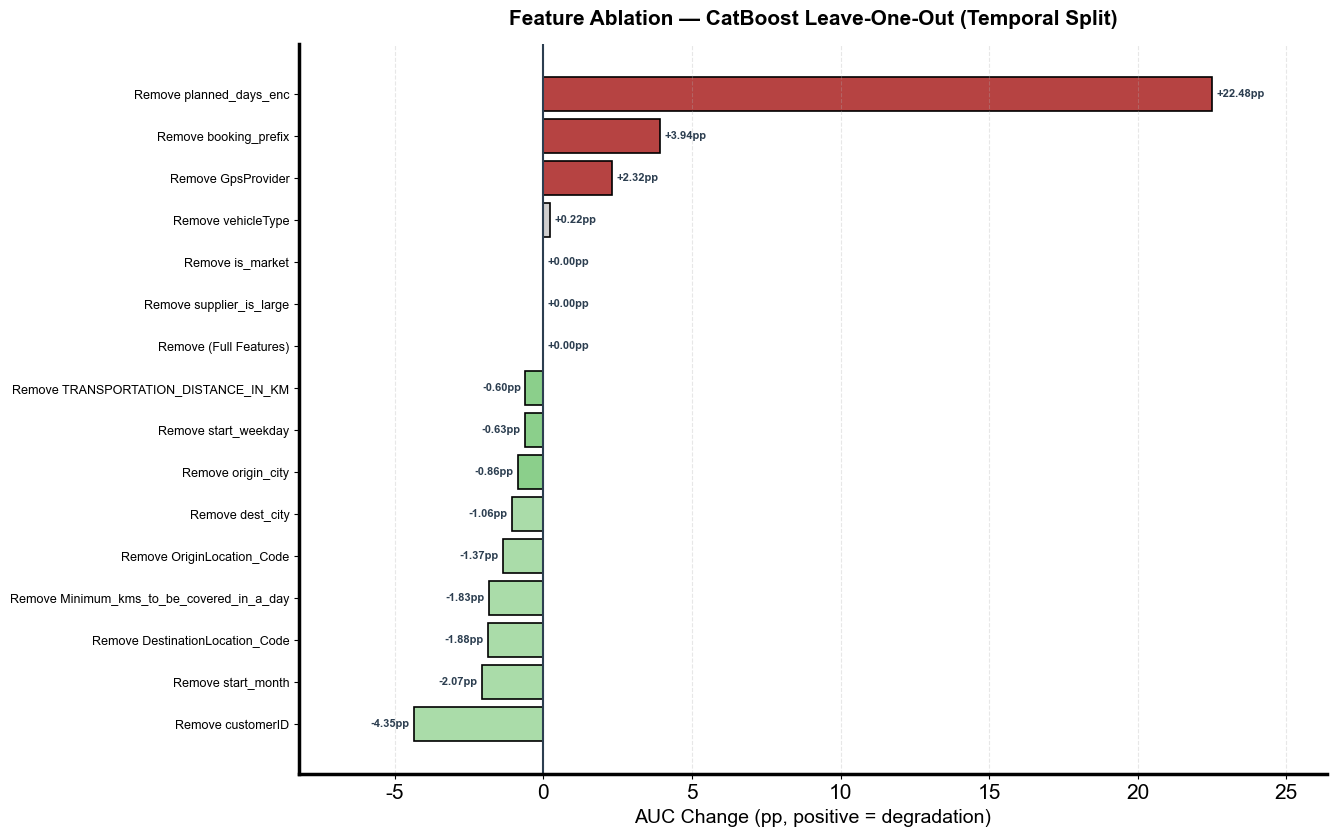

[OK] Saved → C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\figures\models\feature_ablation_bar.png


In [8]:
# ═══════════════════════════════════════════════════
#  Feature ablation bar — sorted by AUC drop
# ═══════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 9))

sub = ablation_results[ablation_results["removed_feat"] != "(All features baseline)"] \
    .sort_values("auc_drop", ascending=True).copy()

def _bar_color(val: float) -> str:
    if val > 1.0:
        return PALETTE['red_strong']
    elif val > 0.3:
        return PALETTE['red_2']
    elif val > -0.3:
        return PALETTE['neutral']
    elif val > -1.0:
        return PALETTE['green_3']
    else:
        return PALETTE['green_2']

colors = [_bar_color(v) for v in sub["auc_drop"]]
bars = ax.barh(range(len(sub)), sub["auc_drop"].values,
               color=colors, edgecolor="black", linewidth=1.2)

ax.axvline(0, color="#2c3e50", linestyle="-", linewidth=1.5)
ax.set_yticks(range(len(sub)))
ax.set_yticklabels(["Remove " + r["removed_feat"] for _, r in sub.iterrows()], fontsize=9)

# Place value labels at bar edges to avoid overlap
for bar, val in zip(bars, sub["auc_drop"].values):
    if val >= 0:
        # Positive: label to the right of bar end
        x_pos = val + 0.15
        ha = "left"
    else:
        # Negative: label to the left of bar end (inside margin)
        x_pos = val - 0.15
        ha = "right"
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"{val:+.2f}pp", va="center", ha=ha,
            fontsize=8, fontweight="bold", color="#2c3e50")

# Add x-axis margin so bars don't collide with ytick labels
x_pad = max(abs(sub["auc_drop"].min()), abs(sub["auc_drop"].max())) * 0.15 + 0.5
ax.set_xlim(sub["auc_drop"].min() - x_pad, sub["auc_drop"].max() + x_pad)

ax.set_xlabel("AUC Change (pp, positive = degradation)", fontsize=14)
ax.set_title("Feature Ablation — CatBoost Leave-One-Out (Temporal Split)",
             fontsize=15, fontweight="bold", pad=14)
ax.grid(axis="x", linestyle="--", alpha=0.3)

fig.tight_layout(pad=2)
fig.savefig(FIGURES_MODELS / 'feature_ablation_bar.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_MODELS / 'feature_ablation_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"[OK] Saved → {FIGURES_MODELS / 'feature_ablation_bar.png'}")

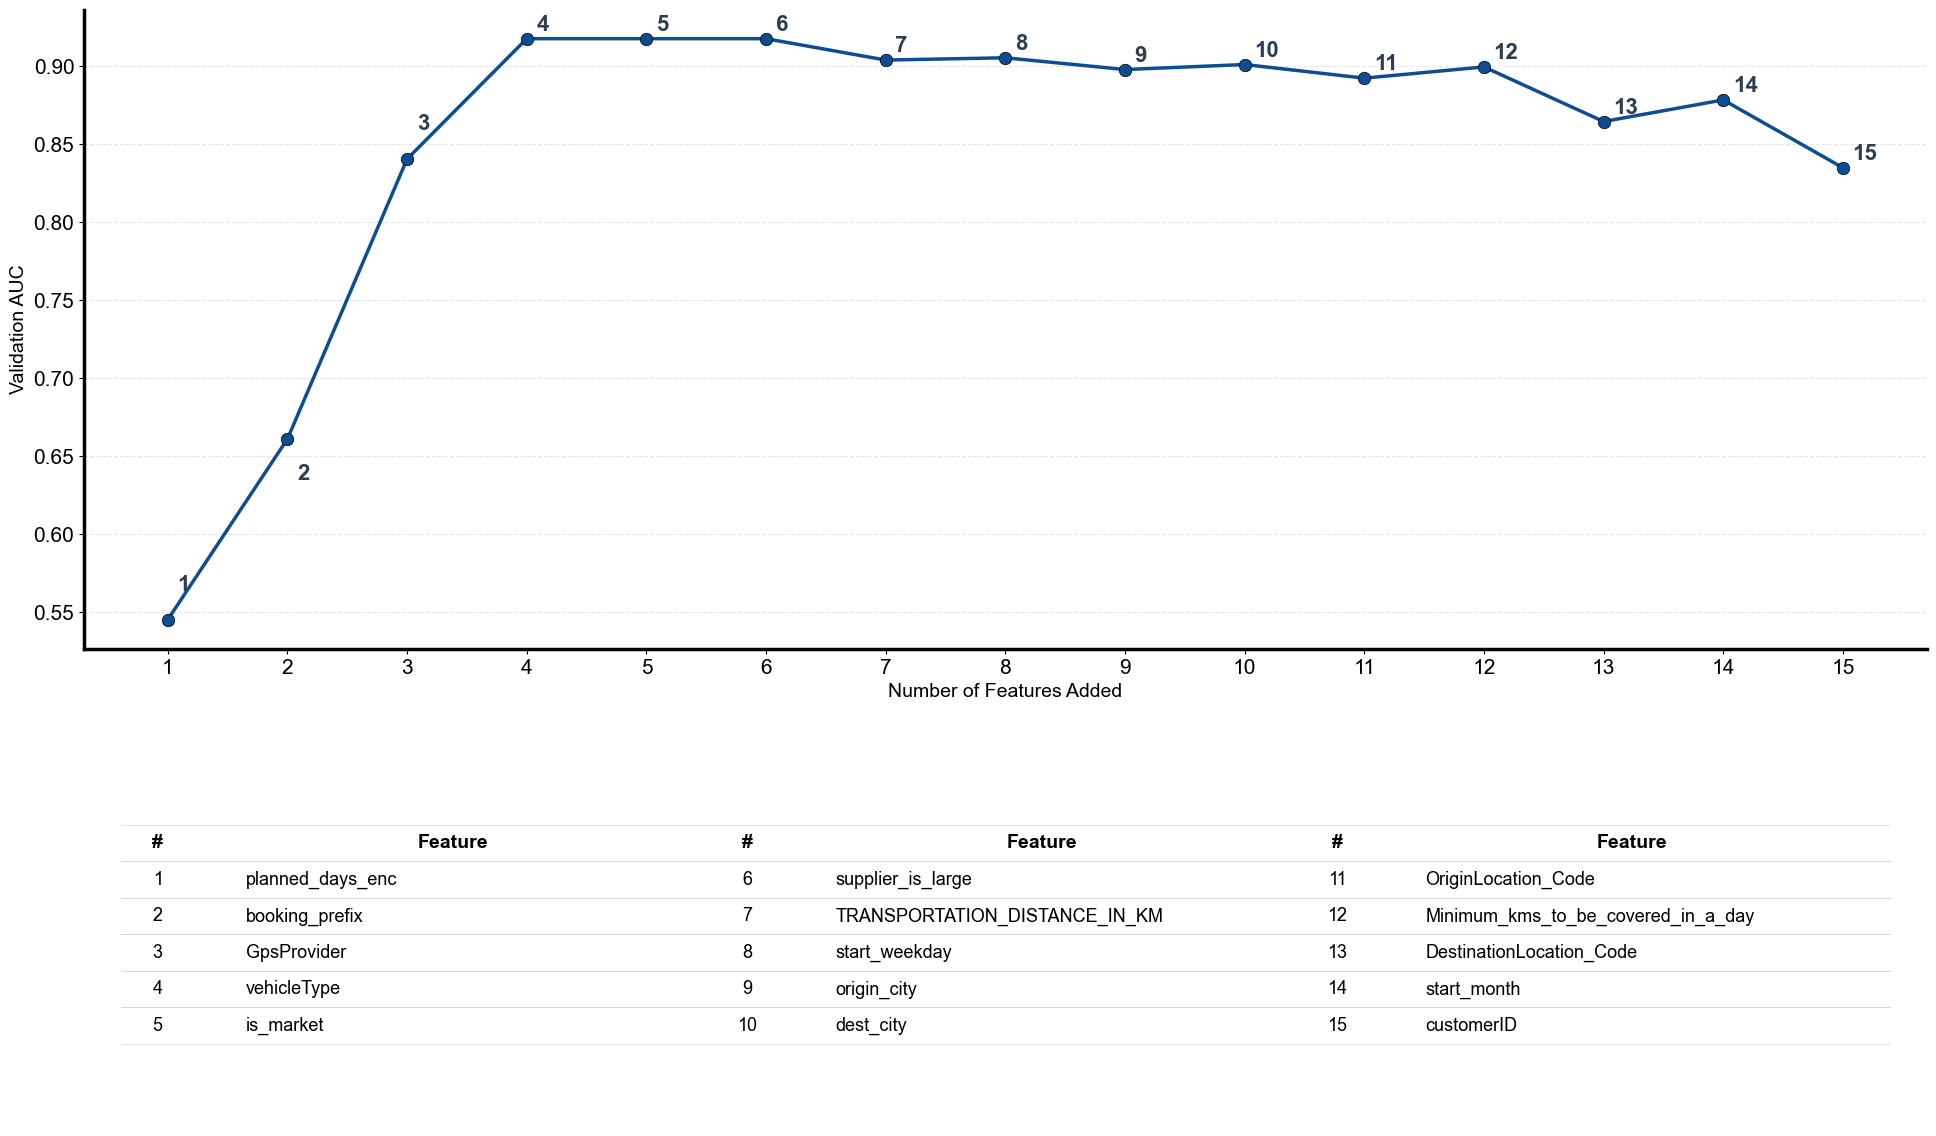

[OK] Saved → C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\figures\models\learning_curves.png


In [9]:
# ═══════════════════════════════════════════════════
#  Cumulative learning curves + index table
# ═══════════════════════════════════════════════════
fig, (ax_plot, ax_tbl) = plt.subplots(
    2, 1, figsize=(20, 12),
    gridspec_kw={"height_ratios": [2, 1.2]},
)

# ── Curves ──
ax_plot.plot(lc_results["n_features"], lc_results["auc"],
             marker="o", linestyle="-", linewidth=2.5, color=PALETTE['blue_main'],
             markersize=9, markeredgecolor='black', markeredgewidth=0.5)

for i, (_, row) in enumerate(lc_results.iterrows()):
    # first 3 points are dense, alternate vertical offset to avoid overlap
    if i < 3:
        y_offset = 18 if i % 2 == 0 else -18
        va = "bottom" if y_offset > 0 else "top"
    else:
        y_offset = 3
        va = "bottom"
    ax_plot.annotate(
        str(i + 1),
        xy=(row["n_features"], row["auc"]),
        xytext=(7, y_offset),
        textcoords="offset points",
        fontsize=16, fontweight="bold", color="#2c3e50",
        va=va, ha="left",
    )

ax_plot.set_xlabel("Number of Features Added", fontsize=14)
ax_plot.set_ylabel("Validation AUC", fontsize=14)
ax_plot.set_xticks(range(1, len(lc_results) + 1))
ax_plot.grid(axis='y', linestyle='--', alpha=0.3)

# ── Index table (re-wrap every 5, 3 groups) ──
ax_tbl.axis("off")
n = len(lc_results)
n_groups = 3
rows_per = 5

flat_headers = []
for g in range(n_groups):
    flat_headers.extend(["#", "Feature"])

tbl_rows = []
for r in range(rows_per):
    row = []
    for g in range(n_groups):
        idx = r + g * rows_per
        if idx < n:
            row.extend([str(idx + 1), lc_results.iloc[idx]["feature_added"]])
        else:
            row.extend(["", ""])
    tbl_rows.append(row)

# column widths in axis coords (must sum ≤ 1.0)
col_ws = [0.04, 0.28, 0.04, 0.28, 0.04, 0.28]

table = ax_tbl.table(
    cellText=tbl_rows,
    colLabels=flat_headers,
    loc="center",
    cellLoc="left",
    colWidths=col_ws,
    edges="horizontal",
)
table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1, 1.8)

for (row_idx, col_idx), cell in table.get_celld().items():
    cell.set_edgecolor("#cccccc")
    cell.set_linewidth(0.4)
    if row_idx == 0:
        cell.set_text_props(fontweight="bold", fontsize=14)
    elif row_idx % 2 == 0:
        cell.set_facecolor("#f0f0f0")
    if col_idx % 2 == 0:
        cell.set_text_props(ha="center")

fig.tight_layout(pad=2)
fig.savefig(FIGURES_MODELS / 'learning_curves.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_MODELS / 'learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"[OK] Saved → {FIGURES_MODELS / 'learning_curves.png'}")

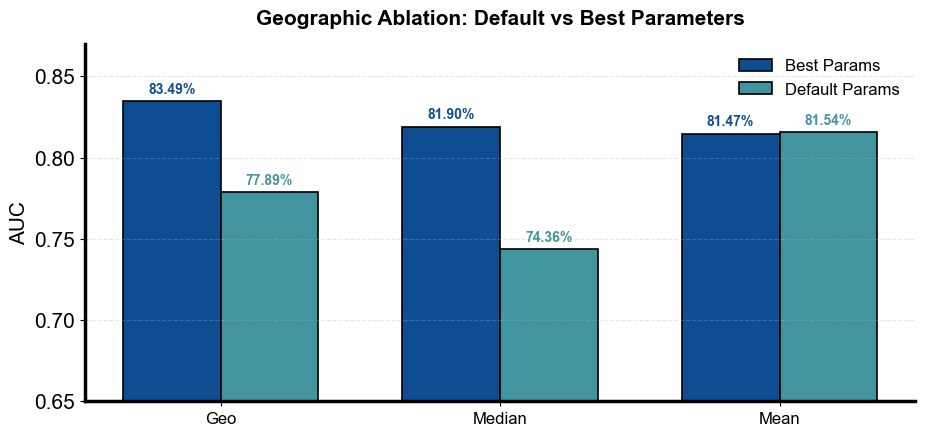

[OK] Saved → C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\figures\models\geo_ablation_default_vs_best.png


In [10]:
# ═══════════════════════════════════════════════════
#  Geo ablation comparison: default vs best params
# ═══════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(geo_results))
width = 0.35

bars_best = ax.bar(x - width/2, geo_results["auc"], width,
                   color=PALETTE['blue_main'], edgecolor='black', linewidth=1.2,
                   label='Best Params')
bars_default = ax.bar(x + width/2, geo_results_default["auc"], width,
                      color=PALETTE['teal'], edgecolor='black', linewidth=1.2,
                      label='Default Params')

for bar, auc_val in zip(bars_best, geo_results["auc"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{auc_val*100:.2f}%", ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=PALETTE['blue_main'])

for bar, auc_val in zip(bars_default, geo_results_default["auc"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{auc_val*100:.2f}%", ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=PALETTE['teal'])

ax.set_xticks(x)
ax.set_xticklabels(geo_results["strategy"], fontsize=12)
ax.set_ylabel("AUC", fontsize=15)
ax.set_title("Geographic Ablation: Default vs Best Parameters",
             fontsize=15, fontweight='bold', pad=14)
ax.legend(fontsize=12)
ax.set_ylim(0.65, 0.87)
ax.grid(axis='y', linestyle='--', alpha=0.3)

fig.tight_layout(pad=2)
fig.savefig(FIGURES_MODELS / 'geo_ablation_default_vs_best.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_MODELS / 'geo_ablation_default_vs_best.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"[OK] Saved → {FIGURES_MODELS / 'geo_ablation_default_vs_best.png'}")